# ¿Cuánto tarda un bosque tropical en volver a la vida?

> **Paper:** Biodiversity resilience in a tropical rainforest  
> **DOI:** [10.1038/s41586-026-10365-2](https://doi.org/10.1038/s41586-026-10365-2) — *Nature* (2026)  
> [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-09-biodiversidad-resiliencia-bosque-tropical/notebook.ipynb)  
> **Video:** [Pendiente]

## El contexto

El 60% de los bosques tropicales del planeta ya se perdió o está muy degradado. ¿Tiene sentido proteger los que están regenerándose? Un equipo midió la recuperación de **16 grupos taxonómicos** — desde bacterias del suelo hasta murciélagos, pasando por árboles, ranas, hormigas y escarabajos — en un bosque tropical de tierras bajas en Ecuador occidental. Usaron 64 parcelas con distinta historia: antiguas plantaciones de cacao, pastizales abandonados y bosques maduros de referencia.

La pregunta central: ¿qué se recupera primero, qué tarda más, y qué mecanismo importa más — resistir la perturbación o regresar después de ella?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_RECUPERACION = 0.90   # 90% = umbral "recuperado" del paper
PERIODO_REFERENCIA = 30      # años
FUENTE = 'Fuente: Giunta et al. (2026), Nature | Datos: Supplementary Materials'
COLOR_BACTERIA = '#059669'   # Emerald
COLOR_ANIMALIA = '#2563EB'   # Azul CaM
COLOR_PLANTAE = '#D97706'    # Amber
COLOR_ALERTA = '#DC2626'     # Rojo

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar datos
df = pd.read_csv('datos/recuperacion_taxa.csv')
df_imp = pd.read_csv('datos/importancia_lambda_resistencia.csv')
df_plots = pd.read_csv('datos/parcelas.csv')

# Paleta por reino
color_map = {'Bacteria': COLOR_BACTERIA, 'Animalia': COLOR_ANIMALIA, 'Plantae': COLOR_PLANTAE}

# Resumen
print(f"Datos cargados: {len(df)} observaciones")
print(f"  {df['Taxon'].nunique()} taxa × {df['Metric'].nunique()} métricas × {df['Legacy'].nunique()} legados")
print(f"  {df_plots.shape[0]} parcelas en Ecuador ({df_plots['Latitude'].mean():.2f}°N, {df_plots['Longitude'].mean():.2f}°W)")
print(f"  Reinos: {', '.join(sorted(df['Kingdom'].unique()))}")
print(f"  Métricas: Abundance, alpha_q0 (riqueza), alpha_q1 (Shannon), alpha_q2 (Simpson), braycurtis (composición)")

Datos cargados: 170 observaciones
  17 taxa × 5 métricas × 2 legados
  64 parcelas en Ecuador (0.51°N, -79.19°W)
  Reinos: Animalia, Bacteria, Plantae
  Métricas: Abundance, alpha_q0 (riqueza), alpha_q1 (Shannon), alpha_q2 (Simpson), braycurtis (composición)


## La recuperación en 30 años

Veamos qué tanto se recupera cada grupo.

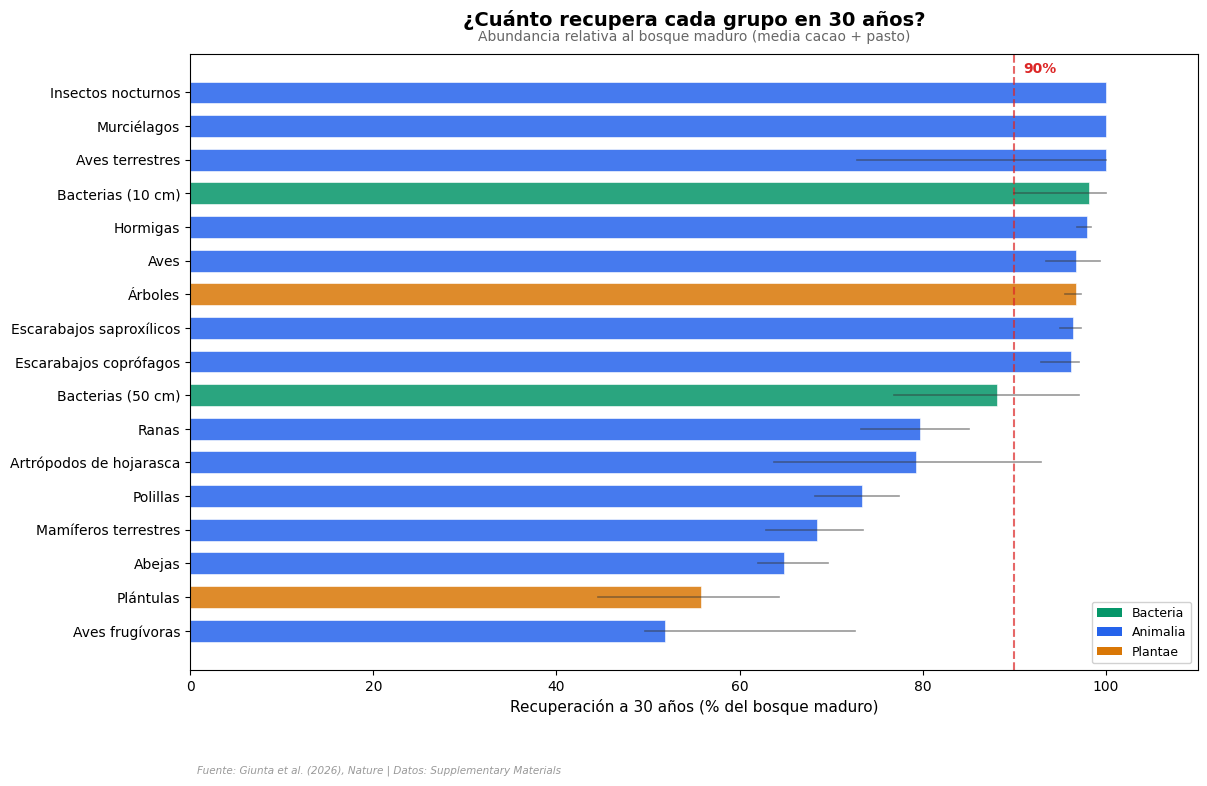

In [2]:
# ── Gráfica hero: Recuperación a 30 años por grupo taxonómico ──
abund = df[df['Metric'] == 'Abundance'].copy()

# Promediar cacao + pasture por taxon
recovery = abund.groupby(['Taxon', 'Kingdom']).agg(
    rr30=('Relative_recovery_30', 'mean'),
    rr30_lo=('Relative_recovery_30_lower_confidence_interval', 'mean'),
    rr30_hi=('Relative_recovery_30_upper_confidence_interval', 'mean'),
    resistance=('Resistance', 'mean')
).reset_index().sort_values('rr30', ascending=True)

# Nombres en español
nombres_es = {
    'Nocturnal insects': 'Insectos nocturnos', 'Birds': 'Aves',
    'Ants': 'Hormigas', 'Bacteria 10 cm depth': 'Bacterias (10 cm)',
    'Bacteria 50 cm depth': 'Bacterias (50 cm)', 'Bats': 'Murciélagos',
    'Bees': 'Abejas', 'Dung beetles': 'Escarabajos coprófagos',
    'Ground birds': 'Aves terrestres', 'Frogs': 'Ranas',
    'Ground mammals': 'Mamíferos terrestres', 'Moths': 'Polillas',
    'Saproxylic beetles': 'Escarabajos saproxílicos', 'Seedlings': 'Plántulas',
    'Frugivorous birds': 'Aves frugívoras', 'Trees': 'Árboles',
    'Leaf-litter arthropods': 'Artrópodos de hojarasca'
}
recovery['Taxon_es'] = recovery['Taxon'].map(nombres_es)
colors = recovery['Kingdom'].map(color_map)

fig, ax = plt.subplots(figsize=(13, 8))
y_pos = np.arange(len(recovery))

# Barras horizontales
bars = ax.barh(y_pos, recovery['rr30'] * 100, height=0.65, color=colors.values,
               alpha=0.85, edgecolor='white', linewidth=0.5)

# Intervalos de confianza
for i, (_, row) in enumerate(recovery.iterrows()):
    ax.plot([row['rr30_lo'] * 100, row['rr30_hi'] * 100], [i, i],
            color='#333333', linewidth=1.2, alpha=0.5, zorder=3)

# Línea de 90%
ax.axvline(x=90, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.7, zorder=2)
ax.text(91, len(recovery) - 0.5, '90%', color=COLOR_ALERTA,
        fontsize=10, fontweight='bold', va='bottom')

ax.set_yticks(y_pos)
ax.set_yticklabels(recovery['Taxon_es'], fontsize=10)
ax.set_xlabel('Recuperación a 30 años (% del bosque maduro)', fontsize=11)
ax.set_title('¿Cuánto recupera cada grupo en 30 años?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Abundancia relativa al bosque maduro (media cacao + pasto)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, 110)

# Leyenda por reino
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_BACTERIA, label='Bacteria'),
    Patch(facecolor=COLOR_ANIMALIA, label='Animalia'),
    Patch(facecolor=COLOR_PLANTAE, label='Plantae')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/recuperacion_30_anos.png', dpi=200, bbox_inches='tight')
plt.show()

## Lectura guiada

La mayoría de los grupos alcanzan o superan el 90% de lo que tiene un bosque maduro — en solo 30 años. La mediana: 94,8% (IQR: 72,5%–100%).

Pero no todos se recuperan igual. Los murciélagos e insectos nocturnos llegan al 100%: estos grupos móviles recolonizan rápido. En el otro extremo, las plántulas (0% de resistencia) y los mamíferos terrestres tardan mucho más — dependen de procesos más lentos como la dispersión de semillas y la reestructuración del sotobosque.

Las aves frugívoras son el caso más difícil: apenas el 52% de recuperación a 30 años. Su dependencia de frutos de árboles maduros — que todavía no están — las frena.

## Resistencia vs velocidad de retorno

Si un grupo resiste bien la perturbación, parte con ventaja. Si no resiste pero regresa rápido, el resultado puede ser igual de bueno. ¿Cuál importa más?

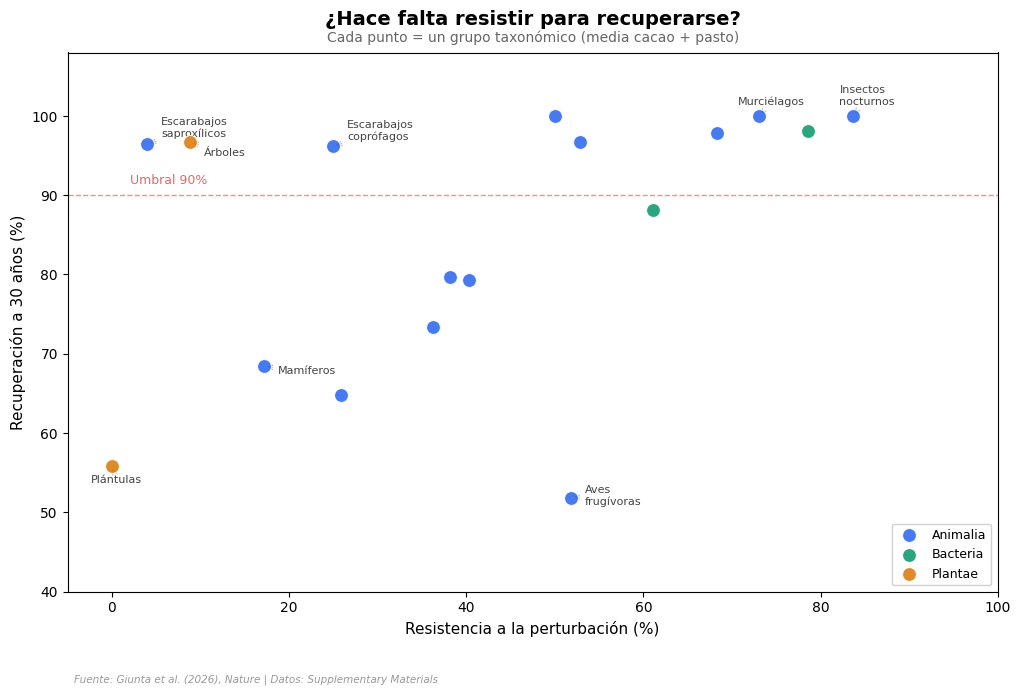

In [3]:
# ── Resistencia vs Recuperación a 30 años ──
fig, ax = plt.subplots(figsize=(12, 7))

for kingdom, group in recovery.groupby('Kingdom'):
    ax.scatter(group['resistance'] * 100, group['rr30'] * 100,
               color=color_map[kingdom], s=100, alpha=0.85,
               edgecolors='white', linewidths=0.8, zorder=5,
               label=kingdom)

# Etiquetar los casos interesantes (inline labels)
labels_to_show = {
    'Seedlings': ('Plántulas', -15, -12),
    'Trees': ('Árboles', 10, -10),
    'Nocturnal insects': ('Insectos\nnocturnos', -10, 8),
    'Bats': ('Murciélagos', -15, 8),
    'Frugivorous birds': ('Aves\nfrugívoras', 10, -5),
    'Ground mammals': ('Mamíferos', 10, -5),
    'Saproxylic beetles': ('Escarabajos\nsaproxílicos', 10, 5),
    'Dung beetles': ('Escarabajos\ncoprófagos', 10, 5),
}
for _, row in recovery.iterrows():
    if row['Taxon'] in labels_to_show:
        name, dx, dy = labels_to_show[row['Taxon']]
        ax.annotate(name, (row['resistance'] * 100, row['rr30'] * 100),
                    xytext=(dx, dy), textcoords='offset points',
                    fontsize=8, color='#444444',
                    arrowprops=dict(arrowstyle='->', color='#BBBBBB', lw=0.8))

# Línea 90%
ax.axhline(y=90, color=COLOR_ALERTA, linewidth=1, linestyle='--', alpha=0.5)
ax.text(2, 91.5, 'Umbral 90%', fontsize=9, color=COLOR_ALERTA, alpha=0.7)

ax.set_xlabel('Resistencia a la perturbación (%)', fontsize=11)
ax.set_ylabel('Recuperación a 30 años (%)', fontsize=11)
ax.set_title('¿Hace falta resistir para recuperarse?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Cada punto = un grupo taxonómico (media cacao + pasto)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-5, 100)
ax.set_ylim(40, 108)
ax.legend(fontsize=9, loc='lower right', framealpha=0.9)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/resistencia_vs_recuperacion.png', dpi=200, bbox_inches='tight')
plt.show()

## La velocidad de retorno importa más

El patrón es claro: hay grupos con resistencia casi nula (plántulas: 0%, escarabajos saproxílicos: 4%) que aún así superan el 90% a 30 años. ¿Cómo? Porque la velocidad de retorno (λ) compensa.

La velocidad de retorno compensa entre 1× y 2,6× más que la resistencia. El efecto es más fuerte para la riqueza de especies (hasta 2,6×) que para la abundancia (~1,7×).

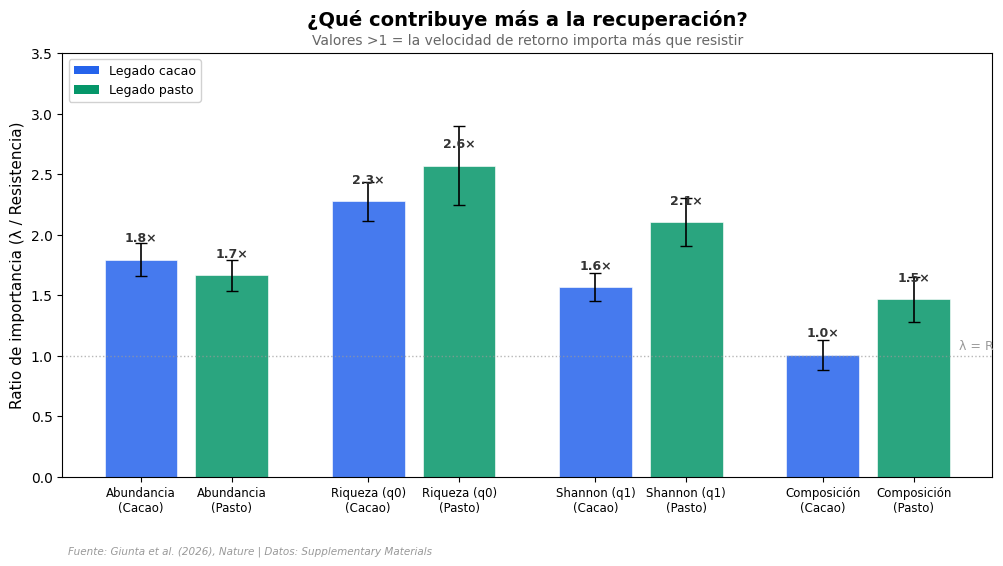

In [4]:
# ── Importancia relativa: Velocidad de retorno (λ) vs Resistencia ──
# Filtrar métricas principales
metricas = ['Abundance', 'alpha_q0', 'alpha_q1', 'braycurtis']
imp = df_imp[df_imp['Metric'].isin(metricas)].copy()

nombres_metricas = {
    'Abundance': 'Abundancia', 'alpha_q0': 'Riqueza (q0)',
    'alpha_q1': 'Shannon (q1)', 'braycurtis': 'Composición'
}
imp['Metric_es'] = imp['Metric'].map(nombres_metricas)
imp['Legacy_es'] = imp['Legacy'].map({'Cacao': 'Cacao', 'Pasture': 'Pasto'})

fig, ax = plt.subplots(figsize=(12, 5.5))

# Agrupar por métrica
x_positions = []
labels = []
colors_bar = []
values = []
errors = []

for i, metric in enumerate(metricas):
    sub = imp[imp['Metric'] == metric].sort_values('Legacy')
    for j, (_, row) in enumerate(sub.iterrows()):
        pos = i * 2.5 + j
        x_positions.append(pos)
        labels.append(f"{nombres_metricas[metric]}\n({row['Legacy_es']})")
        color = '#2563EB' if row['Legacy'] == 'Cacao' else '#059669'
        colors_bar.append(color)
        values.append(row['Importance ratio mean'])
        errors.append(row['Importance ratio standard deviation'])

bars = ax.bar(x_positions, values, width=0.8, color=colors_bar, alpha=0.85,
              edgecolor='white', linewidth=0.5, yerr=errors, capsize=4,
              error_kw={'color': '#666666', 'linewidth': 1.2})

# Línea de referencia λ = R (ratio = 1)
ax.axhline(y=1, color='#999999', linewidth=1, linestyle=':', alpha=0.7)
ax.text(max(x_positions) + 0.5, 1.05, 'λ = R', fontsize=9, color='#999999')

# Valores sobre barras
for pos, val in zip(x_positions, values):
    ax.text(pos, val + 0.15, f'{val:.1f}×', ha='center', fontsize=9, fontweight='bold', color='#333333')

ax.set_xticks(x_positions)
ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylabel('Ratio de importancia (λ / Resistencia)', fontsize=11)
ax.set_title('¿Qué contribuye más a la recuperación?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Valores >1 = la velocidad de retorno importa más que resistir',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 3.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2563EB', label='Legado cacao'),
                   Patch(facecolor='#059669', label='Legado pasto')]
ax.legend(handles=legend_elements, fontsize=9, loc='upper left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/importancia_lambda_resistencia.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Y la composición de especies?

Abundancia y diversidad se recuperan rápido, pero ¿vuelven las mismas especies? La composición — medida como similitud de Bray-Curtis con el bosque maduro — es el indicador más exigente.

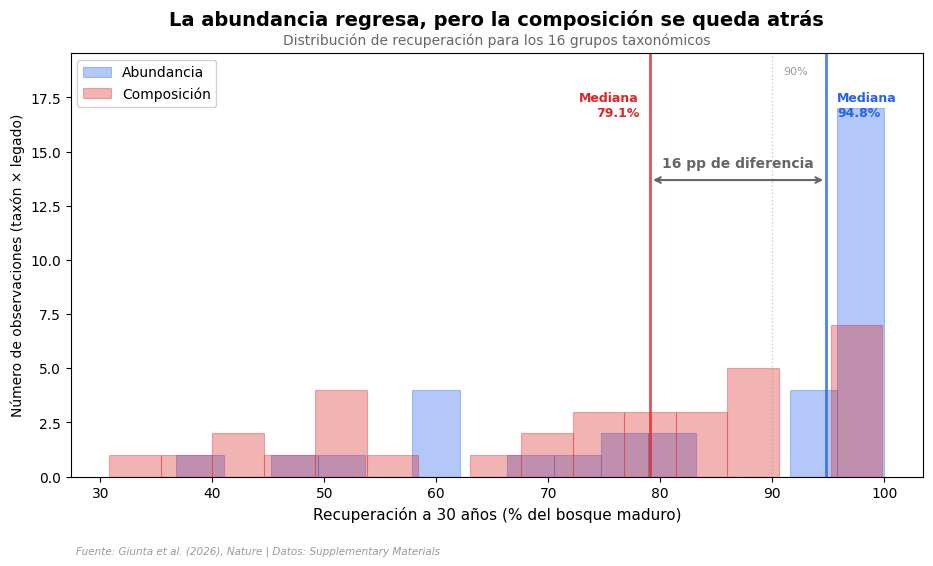

Abundancia — mediana: 94.8%, ≥90%: 21/34
Composición — mediana: 79.1%, ≥90%: 7/34


In [5]:
# ── Histograma: Composición vs Abundancia a 30 años ──
fig, ax = plt.subplots(figsize=(11, 5.5))

# Abundancia
abund_rr = df[(df['Metric'] == 'Abundance')]['Relative_recovery_30'] * 100
# Composición
bray_rr = df[(df['Metric'] == 'braycurtis')]['Relative_recovery_30'] * 100

n1, bins1, patches1 = ax.hist(abund_rr, bins=15, color=COLOR_ANIMALIA, alpha=0.35,
                               edgecolor=COLOR_ANIMALIA, linewidth=0.8, label='Abundancia')
n2, bins2, patches2 = ax.hist(bray_rr, bins=15, color=COLOR_ALERTA, alpha=0.35,
                               edgecolor=COLOR_ALERTA, linewidth=0.8, label='Composición')

# Medianas
med_abund = abund_rr.median()
med_bray = bray_rr.median()
y_max = max(n1.max(), n2.max()) * 1.15
ax.set_ylim(0, y_max)

ax.axvline(x=med_abund, color=COLOR_ANIMALIA, linewidth=2, linestyle='-', alpha=0.8)
ax.axvline(x=med_bray, color=COLOR_ALERTA, linewidth=2, linestyle='-', alpha=0.8)

# Flecha entre medianas
ax.annotate('', xy=(med_bray, y_max * 0.7), xytext=(med_abund, y_max * 0.7),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
gap = abs(med_abund - med_bray)
ax.text((med_abund + med_bray) / 2, y_max * 0.73,
        f'{gap:.0f} pp de diferencia', ha='center', fontsize=10, color='#666666', fontweight='bold')

# Etiquetas de mediana
ax.text(med_abund + 1, y_max * 0.85, f'Mediana\n{med_abund:.1f}%',
        fontsize=9, color=COLOR_ANIMALIA, fontweight='bold')
ax.text(med_bray - 1, y_max * 0.85, f'Mediana\n{med_bray:.1f}%',
        fontsize=9, color=COLOR_ALERTA, fontweight='bold', ha='right')

# Umbral 90%
ax.axvline(x=90, color='#999999', linewidth=1, linestyle=':', alpha=0.5)
ax.text(91, y_max * 0.95, '90%', fontsize=8, color='#999999')

ax.set_xlabel('Recuperación a 30 años (% del bosque maduro)', fontsize=11)
ax.set_ylabel('Número de observaciones (taxón × legado)', fontsize=10)
ax.set_title('La abundancia regresa, pero la composición se queda atrás',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Distribución de recuperación para los 16 grupos taxonómicos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/abundancia_vs_composicion.png', dpi=200, bbox_inches='tight')
plt.show()

# Estadísticas
print(f"Abundancia — mediana: {med_abund:.1f}%, ≥90%: {(abund_rr >= 90).sum()}/{len(abund_rr)}")
print(f"Composición — mediana: {med_bray:.1f}%, ≥90%: {(bray_rr >= 90).sum()}/{len(bray_rr)}")

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Abundancia y diversidad recuperan >90% en 30 años | ✅ | Mediana abundancia: 94,8%, riqueza (q0): 93,2% (n = 34 cada una) |
| Composición alcanza ~75% de similitud | ✅ | Media braycurtis: 73,9%, mediana: 79,1% (IQR: 54,2%–88,7%, n = 34). El paper reporta ~75% |
| Animales móviles resisten mejor que árboles | ✅ | Murciélagos: 73% resistencia, insectos nocturnos: 84%. Plántulas: 0%, árboles: 9% |
| λ contribuye 1–2,5× más que la resistencia | ✅ | Rango en datos: 1,0× (composición-cacao) a 2,6× (riqueza-pasto). Paper: 1–2,5× |
| Los mecanismos simples no explican la variación entre taxa | ⚠️ | Los datos muestran un gradiente resistencia-retorno, pero aves frugívoras (52% RR30) son un caso atípico que rompe patrones simples |

> **Limitaciones:** (1) Diseño observacional (crono-secuencia) — la "recuperación" se infiere de sitios de diferente edad, no de seguimiento longitudinal. (2) Los datos del suplementario son promedios del modelo ajustado, no datos crudos de campo. (3) Solo un sitio geográfico (Ecuador occidental) — la generalización a otros bosques tropicales requiere cautela. (4) El paper dice 16 grupos taxonómicos; los datos suplementarios contienen 17 con flag `IncludeTaxon=1` — posiblemente 2 bacterias cuentan como 1 en el texto.

---

## Ahora tú

1. **¿Qué pasa con la composición más allá de 30 años?** El modelo estima tiempos de recuperación completa para cada taxón. ¿Cuáles grupos tardan >100 años en recuperar su composición original? (Pista: filtra por `Metric == 'braycurtis'` y `Recoverytime`)

2. **¿El tipo de perturbación importa?** Separa la recuperación por `Legacy` (cacao vs pasto). ¿Hay grupos que se recuperan mucho mejor de uno que del otro? (Pista: pivotea con `groupby(['Taxon', 'Legacy'])`)

3. **¿Hay un patrón por nivel trófico?** Los datos incluyen información trófica (`Trophic`, `TrophicLevel`). ¿Los depredadores se recuperan diferente que los herbívoros? (Pista: merge con la columna `Trophic` y agrupa)

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta: ¿El tipo de perturbación (cacao vs pasto) genera diferencias?

abund = df[df['Metric'] == 'Abundance'].copy()

# Pivot: una fila por taxón, columnas por legado
pivot = abund.pivot_table(
    index='Taxon', columns='Legacy',
    values='Relative_recovery_30', aggfunc='mean'
)
pivot['diferencia'] = (pivot['cacao'] - pivot['pasture']) * 100

print("Recuperación a 30 años: Cacao vs Pasto")
print("=" * 55)
for taxon, row in pivot.sort_values('diferencia', ascending=False).iterrows():
    c = row.get('cacao', float('nan'))
    p = row.get('pasture', float('nan'))
    d = row.get('diferencia', float('nan'))
    signo = '+' if d > 0 else ''
    print(f"  {taxon:30} Cacao: {c*100:5.1f}%  Pasto: {p*100:5.1f}%  Δ: {signo}{d:.1f} pp")

Recuperación a 30 años: Cacao vs Pasto
  Ground mammals                 Cacao: 100.0%  Pasto:  36.8%  Δ: +63.2 pp
  Dung beetles                   Cacao: 100.0%  Pasto:  92.3%  Δ: +7.7 pp
  Saproxylic beetles             Cacao: 100.0%  Pasto:  92.9%  Δ: +7.1 pp
  Trees                          Cacao: 100.0%  Pasto:  93.4%  Δ: +6.6 pp
  Birds                          Cacao: 100.0%  Pasto:  93.5%  Δ: +6.5 pp
  Bacteria 10 cm depth           Cacao: 100.0%  Pasto:  96.2%  Δ: +3.8 pp
  Ants                           Cacao:  99.7%  Pasto:  96.1%  Δ: +3.6 pp
  Ground birds                   Cacao: 100.0%  Pasto: 100.0%  Δ: 0.0 pp
  Bats                           Cacao: 100.0%  Pasto: 100.0%  Δ: 0.0 pp
  Nocturnal insects              Cacao: 100.0%  Pasto: 100.0%  Δ: 0.0 pp
  Frogs                          Cacao:  78.5%  Pasto:  80.8%  Δ: -2.3 pp
  Moths                          Cacao:  71.7%  Pasto:  75.0%  Δ: -3.3 pp
  Seedlings                      Cacao:  53.5%  Pasto:  58.1%  Δ: -4.6 pp
 

---

## Créditos

- **Paper:** Giunta et al. (2026). *Biodiversity resilience in a tropical rainforest*. Nature. DOI: [10.1038/s41586-026-10365-2](https://doi.org/10.1038/s41586-026-10365-2)
- **Datos:** Supplementary Materials (Nature) — 9 CSVs + 1 XLSX
- **Código y datos:** CodeOcean repository ([10.24433/CO.1040081.v4](https://doi.org/10.24433/CO.1040081.v4))
- **Licencia:** Datos bajo licencia del editor. Notebook bajo [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)
- **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)